In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
df = pd.read_csv("../data/t20_first_innings.csv")
df.head()


,over,ball,current_score,wickets,balls_remaining,runs_last_5_overs,final_score
0,0,1,1,0,119,1,104
1,0,2,1,0,118,1,104
2,0,3,2,0,117,2,104
3,0,4,6,0,116,6,104
4,0,5,6,0,115,6,104


In [44]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39241 entries, 0 to 39240
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   over               39241 non-null  int64
 1   ball               39241 non-null  int64
 2   current_score      39241 non-null  int64
 3   wickets            39241 non-null  int64
 4   balls_remaining    39241 non-null  int64
 5   runs_last_5_overs  39241 non-null  int64
 6   final_score        39241 non-null  int64
dtypes: int64(7)
memory usage: 2.1 MB
None


In [45]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 over                 0
ball                 0
current_score        0
wickets              0
balls_remaining      0
runs_last_5_overs    0
final_score          0
dtype: int64


In [46]:
print("\nDescriptive stats:\n", df.describe())


Descriptive stats:
                over          ball  current_score  wickets  balls_remaining  \
count  39241.000000  39241.000000   39241.000000  39241.0      39241.00000   
mean       9.222344      3.661910      58.269055      0.0         58.10963   
std        5.730921      1.846599      43.418610      0.0         35.99125   
min        0.000000      1.000000       0.000000      0.0        -23.00000   
25%        4.000000      2.000000      22.000000      0.0         27.00000   
50%        9.000000      4.000000      51.000000      0.0         59.00000   
75%       14.000000      5.000000      85.000000      0.0         89.00000   
max       19.000000     13.000000     270.000000      0.0        119.00000   

       runs_last_5_overs   final_score  
count       39241.000000  39241.000000  
mean           25.781988    124.225657  
std            14.337763     44.249015  
min             0.000000      9.000000  
25%            16.000000     92.000000  
50%            25.000000    12

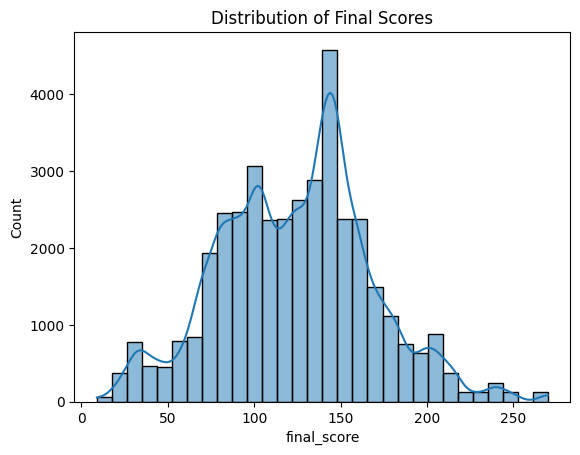

In [47]:
sns.histplot(df['final_score'], kde=True, bins=30)
plt.title("Distribution of Final Scores")
plt.show()

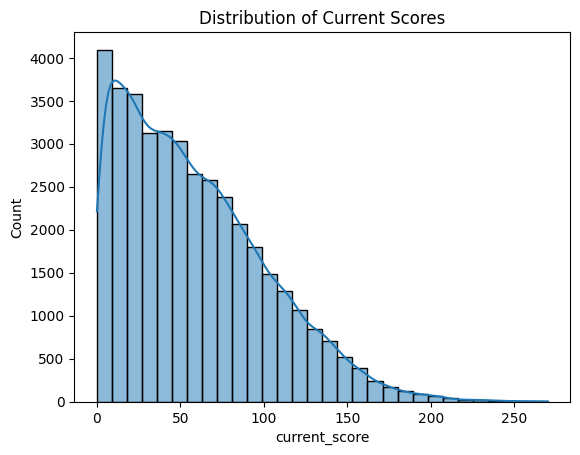

In [48]:
sns.histplot(df['current_score'], kde=True, bins=30)
plt.title("Distribution of Current Scores")
plt.show()


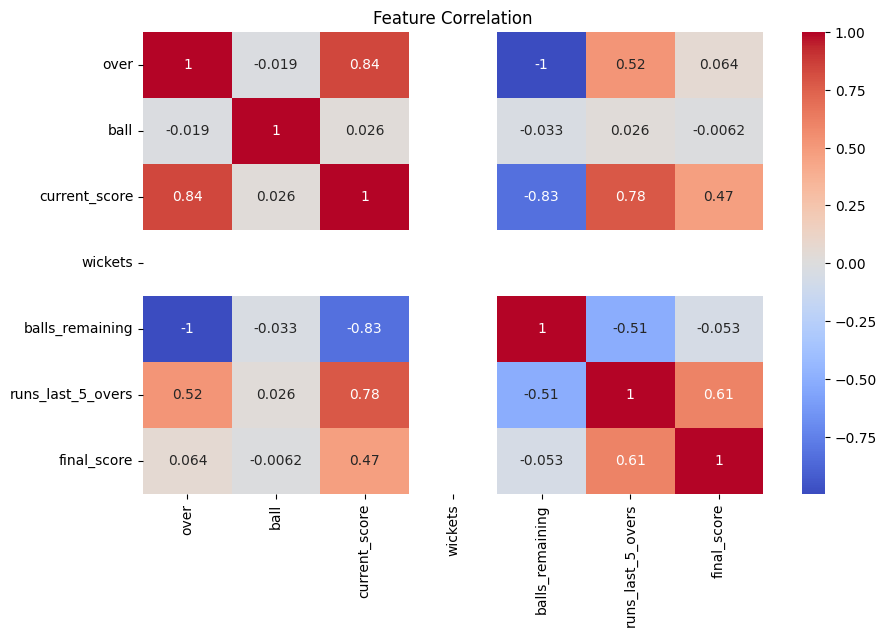

In [49]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [50]:
# Run rate so far
df['run_rate'] = df['current_score'] / (df['over'] + df['ball']/6 + 1e-5)

# Wickets effect (dummy example: wickets remaining)
df['wickets_remaining'] = 10 - df['wickets']

# Runs per last 5 overs normalized
df['runs_last_5_normalized'] = df['runs_last_5_overs'] / 5

# Feature and target selection
X = df[['over', 'ball', 'current_score', 'wickets', 'balls_remaining', 
        'runs_last_5_overs', 'run_rate', 'wickets_remaining', 'runs_last_5_normalized']]
y = df['final_score']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
# 6a️⃣ Linear Regression (Simple Baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

# Metrics for Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Metrics:")
print(f"MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, R2: {r2_lr:.2f}")


Linear Regression Metrics:
MAE: 18.04, RMSE: 25.19, R2: 0.67


In [55]:

# 6b️⃣ Random Forest Regressor (Advanced Model)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [59]:


mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Metrics")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)


Random Forest Metrics
MAE : 16.394585985440482
RMSE: 24.673508079966265
R²  : 0.6839531854355847


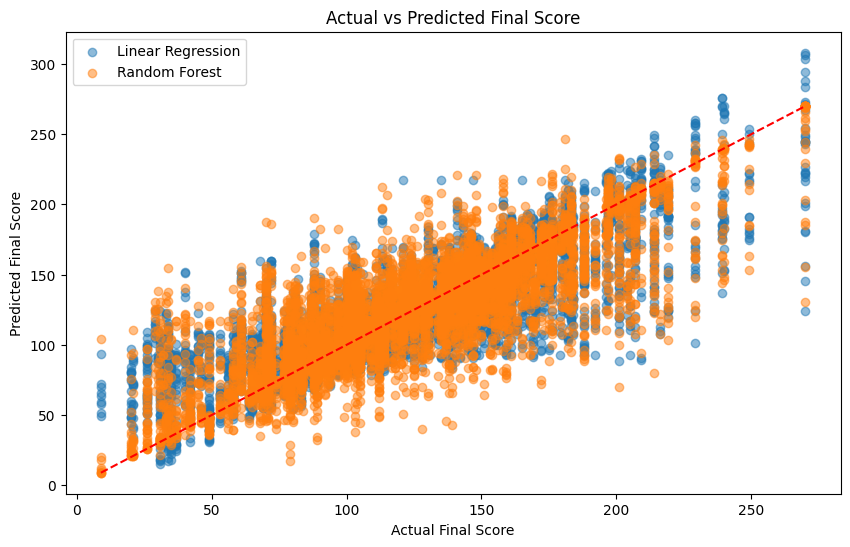

In [60]:
# Visualization: Actual vs Predicted

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, label="Linear Regression")
plt.scatter(y_test, y_pred_rf, alpha=0.5, label="Random Forest")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score")
plt.legend()
plt.show()

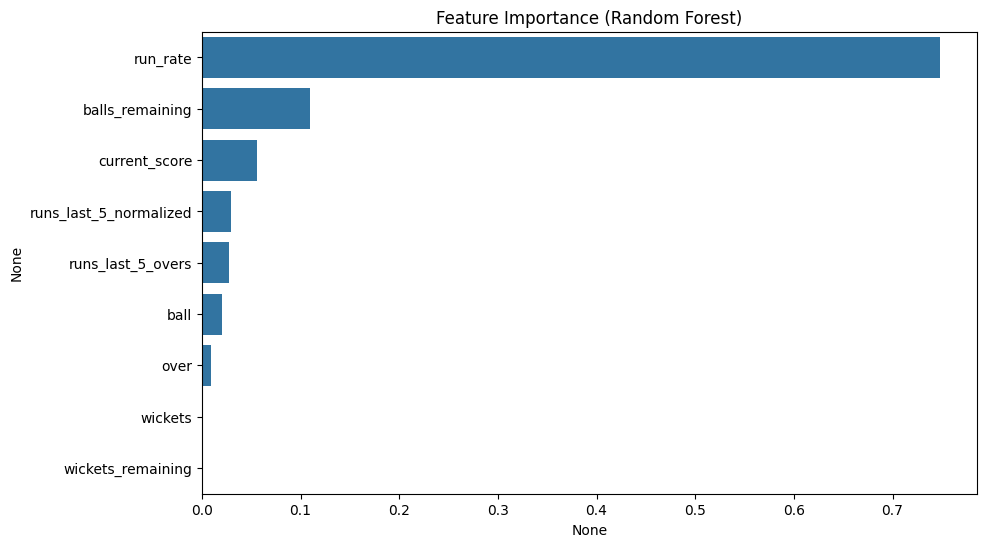

In [61]:
# Feature Importance (Random Forest)
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature Importance (Random Forest)")
plt.show()